# 01. 데이터 이해와 PCA

**목표**: 여가생활 설문 데이터(2,600명, 14개 변수)의 분포를 확인하고, 표준화 후 PCA로 2차원에 투영해 군집분석 입력을 만든다.

| 단계 | 처리 | 이유 |
|---|---|---|
| 결측값 보정 | `SimpleImputer(mean)` | 서비스에서 사용자가 일부 문항을 비워도 예측이 가능하도록 |
| 표준화 | `StandardScaler` | 시간(0~18)과 비율(0~100)처럼 단위가 다른 변수가 거리 계산을 지배하지 않도록 |
| 차원 축소 | `PCA(n_components=2)` | 14차원 → 2차원. 군집 경계를 시각적으로 확인하고 부스 현장에서 설명하기 쉽게 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common import *
setup_plot()
pd.set_option("display.width", 200)
df = load_data()

## 1. 데이터 개요

In [2]:
print(df.shape)
df.rename(columns=FEATURE_KO).describe().T[["mean", "std", "min", "max"]].round(2)

(2600, 14)


,mean,std,min,max
가구소득,1.81,1.66,0.0,4.0
여가목적 1순위,3.83,2.21,1.0,9.0
여가목적 2순위,3.90,2.35,0.0,9.0
평일 여가시간,3.22,2.24,0.0,16.0
주말 여가시간,5.97,3.47,0.0,18.0
휴식·오락 비율,42.23,26.22,0.0,100.0
취미 비율,18.88,20.18,0.0,100.0
자기계발 비율,13.15,16.10,0.0,100.0
대인관계 비율,23.19,20.46,0.0,100.0
관심활동 1순위,3.69,2.33,1.0,8.0


PosixPath('/home/claude/ydplab/analysis/figures/01_distribution.png')

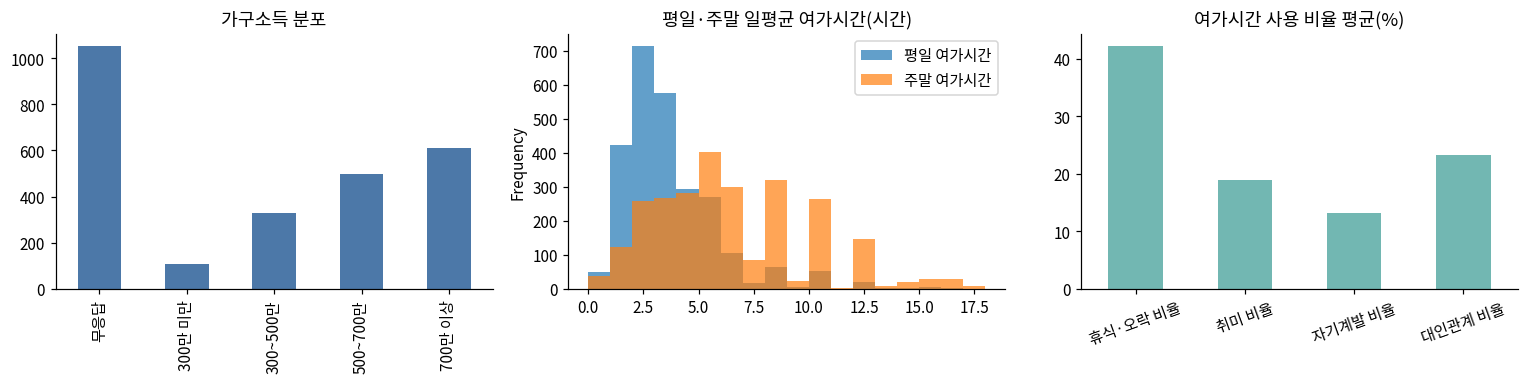

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
df["household_income"].map(INCOME).value_counts().reindex(INCOME.values()).plot.bar(ax=axes[0], color="#4C78A8")
axes[0].set_title("가구소득 분포"); axes[0].set_xlabel("")
df[["weekday_avg_leisure_time", "weekend_avg_leisure_time"]].rename(columns=FEATURE_KO).plot.hist(bins=18, alpha=.7, ax=axes[1])
axes[1].set_title("평일·주말 일평균 여가시간(시간)")
df[RATIO_COLS[2:]].rename(columns=FEATURE_KO).mean().plot.bar(ax=axes[2], color="#72B7B2")
axes[2].set_title("여가시간 사용 비율 평균(%)"); axes[2].tick_params(axis="x", rotation=20)
fig.tight_layout(); save(fig, "01_distribution.png")

**관찰**
- 가구소득은 `무응답(0)` 비중이 가장 크다 → 무응답을 결측으로 지우지 않고 하나의 응답 범주로 유지했다.
- 주말 여가시간(평균 약 6.0시간)이 평일(약 3.2시간)의 두 배 수준.
- 여가시간의 약 42%를 휴식·오락에 사용한다. 이 비율이 군집을 나누는 핵심 축이 된다.

## 2. 표준화 + PCA

PC1 14.2%, PC2 12.7%, 누적 27.0%


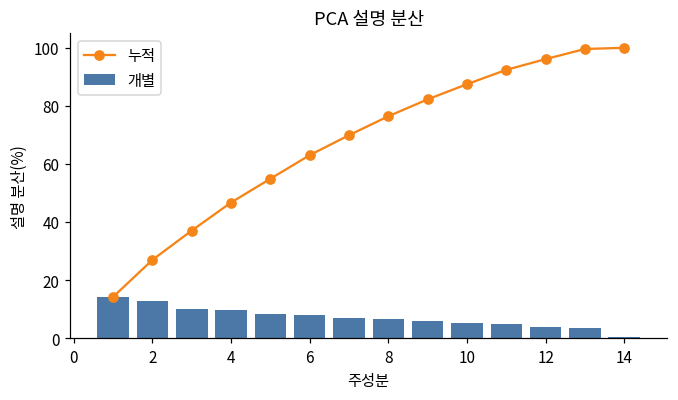

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

Z = StandardScaler().fit_transform(SimpleImputer().fit_transform(df[FEATURES]))
pca_full = PCA(random_state=RANDOM_STATE).fit(Z)
evr = pca_full.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(range(1, len(evr) + 1), evr * 100, color="#4C78A8", label="개별")
ax.plot(range(1, len(evr) + 1), np.cumsum(evr) * 100, "o-", color="#F58518", label="누적")
ax.set_xlabel("주성분"); ax.set_ylabel("설명 분산(%)"); ax.set_title("PCA 설명 분산"); ax.legend()
save(fig, "01_pca_variance.png")
print(f"PC1 {evr[0]:.1%}, PC2 {evr[1]:.1%}, 누적 {evr[:2].sum():.1%}")

In [5]:
loadings = pd.DataFrame(pca_full.components_[:2].T, index=[FEATURE_KO[f] for f in FEATURES], columns=["PC1", "PC2"])
loadings.round(2).sort_values("PC1")

,PC1,PC2
여가목적 1순위,-0.17,-0.20
취미 비율,-0.17,-0.41
관심활동 1순위,-0.05,0.12
대인관계 비율,-0.01,-0.19
자기계발 비율,0.01,-0.26
가구소득,0.05,-0.23
여가목적 2순위,0.08,-0.16
휴식·오락 비율,0.14,0.63
평일 여가시간,0.23,0.21
주말 여가시간,0.27,0.22


PosixPath('/home/claude/ydplab/analysis/figures/01_pca_scatter.png')

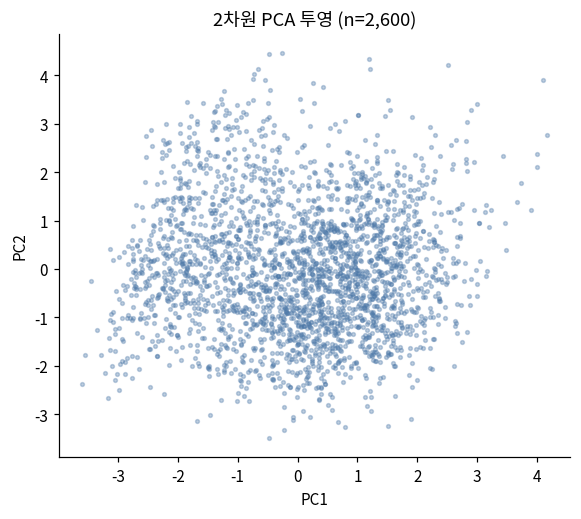

In [6]:
P = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Z)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P[:, 0], P[:, 1], s=6, alpha=.35, color="#4C78A8")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title("2차원 PCA 투영 (n=2,600)")
save(fig, "01_pca_scatter.png")

**정리**
- 2개 주성분이 전체 분산의 약 27%를 설명한다. 정보 손실이 크다는 점은 한계로 인지하고 있었고, 대신 **해석 가능성**(2D에서 군집을 직접 보고 설명)과 **군집 분리도**(차원을 늘릴수록 실루엣 점수가 낮아짐, 02 노트북)를 우선했다.
- PC1·PC2의 적재값을 보면 휴식·오락 비율 ↔ 취미·자기계발·대인관계 비율, 여가시간 길이가 주된 축이다.